# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A model is "linear" in its parameters, not necessarily in the features. So y_hat = b0 + b1*x1 + b2*x2 is linear because we're just taking a weighted sum of the b's. But even something like y = b0 + b1*x + b2*x^2 is still linear because it's still linear in b0, b1, b2 -- the x^2 is just treated as another feature.

2. This depends on whether theres an intercept or not. If you have an intercept, you need to drop one category to avoid the dummy variable trap. Then the coefficient on each dummy tells you how different that category is from the dropped one (the reference). If theres no intercept, you can keep all the dummies and each coefficient is just the mean of y for that group.

3. You can, its called a linear probability model where you regress a 0/1 variable on features. The predictions are like probabilities. But its not great because predictions can go below 0 or above 1 which doesnt make sense for a probability, and the errors are heteroskedastic. Logistic regression handles this better which is why we usually use that instead.

4. Big gap between training R2 and test R2, training RMSE way lower than test RMSE, really large coefficients, and the worst sign is when test R2 goes negative meaning your model is doing worse than just guessing the mean.

5. With two-stage least squares, you first regress x1 on x2 to get the residuals, which is basically the part of x1 that x2 cant explain. Then you regress y on those residuals. If x1 and x2 are super correlated (multicollinear), then x2 explains almost all of x1 so the leftover residuals have barely any variation. That means in the second stage, the coefficient is really unstable and has a huge standard error. So basically multicollinearity makes it really hard to tell apart each variables individual effect on y.

6. You can transform the features to capture nonlinear patterns while still using linear regression. Like adding x^2 or x^3 terms, taking the log or arcsinh of variables, adding interaction terms like x1*x2, or using PolynomialFeatures from sklearn to do it automatically. The model is still linear in the coefficients even though the relationship with the original x is curved.

7. The intercept b0 is the predicted y when all x variables are 0. A slope coefficient like b1 means for every 1 unit increase in that x, y goes up by b1 (holding everything else constant). For a dummy variable coefficient, it tells you the difference in predicted y between that category and whichever category was dropped as the reference.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

Average Price and Review Scores by Neighbourhood:
                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750

Most expensive borough on average: Manhattan



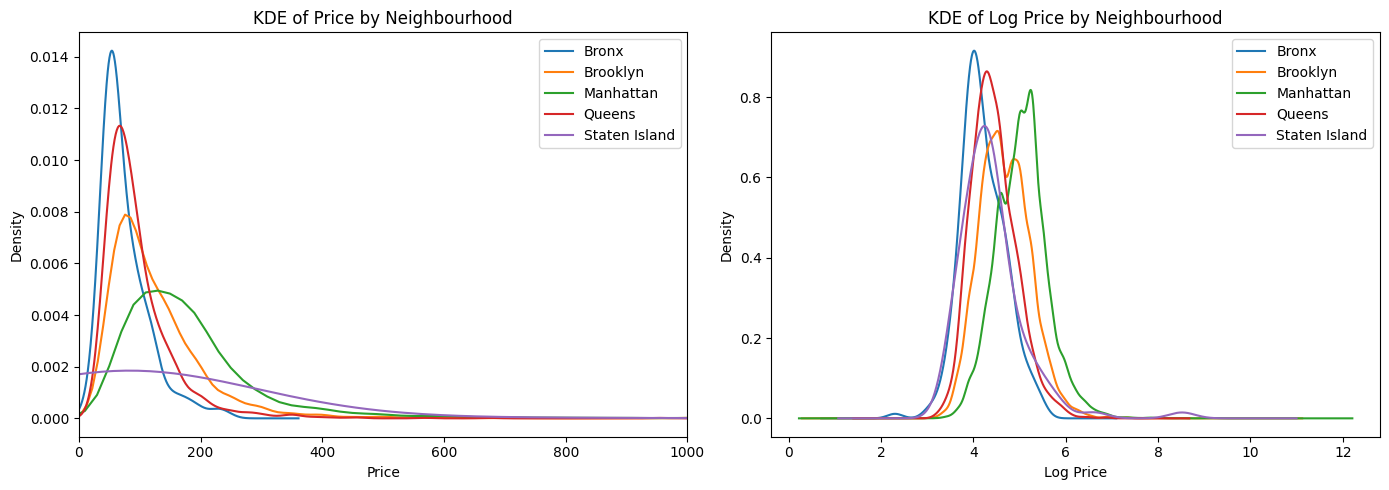

In [2]:
#Q2.1 - load data, get averages by neighbourhood
df = pd.read_csv('./data/Q1_clean.csv')

#avg price and ratings by neighbourhood
avg_by_neighbourhood = df.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
print('Average Price and Review Scores by Neighbourhood:')
print(avg_by_neighbourhood)
print()

#which one is the most expensive
most_expensive = avg_by_neighbourhood['Price'].idxmax()
print(f'Most expensive borough on average: {most_expensive}')
print()

#kde plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#price
for name, group in df.groupby('Neighbourhood '):
    group['Price'].plot.kde(ax=axes[0], label=name)
axes[0].set_title('KDE of Price by Neighbourhood')
axes[0].set_xlabel('Price')
axes[0].set_xlim(0, 1000)
axes[0].legend()

#log price
df['log_Price'] = np.log(df['Price'])
for name, group in df.groupby('Neighbourhood '):
    group['log_Price'].plot.kde(ax=axes[1], label=name)
axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].set_xlabel('Log Price')
axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
#Q2.2 - regress price on neighbourhood dummies, no intercept
#keep all dummies since theres no intercept
dummies_all = pd.get_dummies(df['Neighbourhood '], dtype=float)

#no intercept
model_no_intercept = LinearRegression(fit_intercept=False)
model_no_intercept.fit(dummies_all, df['Price'])

#coefficients
coef_no_intercept = pd.Series(model_no_intercept.coef_, index=dummies_all.columns)
print('Coefficients (no intercept):')
print(coef_no_intercept)
print()

#compare to means
print('Group means from part 1:')
print(avg_by_neighbourhood['Price'])
print()

#the coefficients match the group means exactly
#so when you regress y on dummies for one categorical variable
#with no intercept, each coef is just the mean of y for that group

Coefficients (no intercept):
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64

Group means from part 1:
Neighbourhood 
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64



In [4]:
#Q2.3 - same thing but with an intercept, so drop one dummy
dummies_drop = pd.get_dummies(df['Neighbourhood '], drop_first=True, dtype=float)

model_with_intercept = LinearRegression(fit_intercept=True)
model_with_intercept.fit(dummies_drop, df['Price'])

print(f'Intercept: {model_with_intercept.intercept_:.4f}')
coef_with_intercept = pd.Series(model_with_intercept.coef_, index=dummies_drop.columns)
print('Coefficients:')
print(coef_with_intercept)
print()

#the dropped category is Bronx (first alphabetically)
ref_category = sorted(df['Neighbourhood '].unique())[0]
print(f'Dropped category: {ref_category}')
print()

#intercept = mean price of the reference (Bronx)
#each coef = difference from Bronx's mean
#to get the part 2 coefs back, just add intercept + coef for each
print('Getting part 2 coefficients back:')
print(f'{ref_category}: {model_with_intercept.intercept_:.4f} (just the intercept)')
for cat in dummies_drop.columns:
    val = model_with_intercept.intercept_ + coef_with_intercept[cat]
    print(f'{cat}: {val:.4f} (intercept + coef)')

Intercept: 75.2765
Coefficients:
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64

Dropped category: Bronx

Getting part 2 coefficients back:
Bronx: 75.2765 (just the intercept)
Brooklyn: 127.7474 (intercept + coef)
Manhattan: 183.6643 (intercept + coef)
Queens: 96.8572 (intercept + coef)
Staten Island: 146.1667 (intercept + coef)


In [5]:
#Q2.4 - price on review scores + neighbourhood
X_q2_4 = pd.get_dummies(df[['Review Scores Rating', 'Neighbourhood ']], columns=['Neighbourhood '], drop_first=True, dtype=float)
y_q2 = df['Price']

X_train4, X_test4, y_train4, y_test4 = train_test_split(X_q2_4, y_q2, test_size=0.2, random_state=42)

model4 = LinearRegression()
model4.fit(X_train4, y_train4)
y_pred4 = model4.predict(X_test4)

r2_4 = r2_score(y_test4, y_pred4)
rmse_4 = np.sqrt(mean_squared_error(y_test4, y_pred4))

print(f'Test R2: {r2_4:.4f}')
print(f'Test RMSE: {rmse_4:.4f}')
print()

coefs4 = pd.Series(model4.coef_, index=X_train4.columns)
print(f'Review Scores Rating coef: {coefs4["Review Scores Rating"]:.4f}')
print()

#find the most expensive neighbourhood
neighbourhood_coefs4 = coefs4.drop('Review Scores Rating')
print('Neighbourhood coefs:')
print(neighbourhood_coefs4)

#need to include the reference category (coef=0) to compare properly
ref_cat = sorted(df['Neighbourhood '].unique())[0]
all_effects = neighbourhood_coefs4.copy()
all_effects[f'Neighbourhood _{ref_cat}'] = 0
most_exp = all_effects.idxmax()
print(f'\nMost expensive: {most_exp}')

Test R2: 0.0459
Test RMSE: 140.9182

Review Scores Rating coef: 1.2119

Neighbourhood coefs:
Neighbourhood _Brooklyn          51.555970
Neighbourhood _Manhattan        107.413553
Neighbourhood _Queens            20.198573
Neighbourhood _Staten Island     23.454672
dtype: float64

Most expensive: Neighbourhood _Manhattan


/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [6]:
#Q2.5 - now add Property Type too
X_q2_5 = pd.get_dummies(df[['Review Scores Rating', 'Neighbourhood ', 'Property Type']],
                        columns=['Neighbourhood ', 'Property Type'], drop_first=True, dtype=float)
y_q2 = df['Price']

X_train5, X_test5, y_train5, y_test5 = train_test_split(X_q2_5, y_q2, test_size=0.2, random_state=42)

model5 = LinearRegression()
model5.fit(X_train5, y_train5)
y_pred5 = model5.predict(X_test5)

r2_5 = r2_score(y_test5, y_pred5)
rmse_5 = np.sqrt(mean_squared_error(y_test5, y_pred5))

print(f'Test R2: {r2_5:.4f}')
print(f'Test RMSE: {rmse_5:.4f}')
print()

coefs5 = pd.Series(model5.coef_, index=X_train5.columns)
print(f'Review Scores Rating coef: {coefs5["Review Scores Rating"]:.4f}')
print()

#find most expensive property type
property_coefs = coefs5[[c for c in coefs5.index if 'Property Type' in c]]
print('Property Type coefs:')
print(property_coefs)

ref_prop = sorted(df['Property Type'].unique())[0]
all_prop_effects = property_coefs.copy()
all_prop_effects[f'Property Type_{ref_prop}'] = 0
most_exp_prop = all_prop_effects.idxmax()
print(f'\nMost expensive property type: {most_exp_prop}')

Test R2: 0.0542
Test RMSE: 140.3027

Review Scores Rating coef: 1.2010

Property Type coefs:
Property Type_Bed & Breakfast    -28.703920
Property Type_Boat                47.070419
Property Type_Bungalow            83.972440
Property Type_Cabin               12.389621
Property Type_Camper/RV          -13.817125
Property Type_Castle             -41.810548
Property Type_Chalet             -30.237720
Property Type_Condominium         61.907162
Property Type_Dorm               -42.277758
Property Type_House               34.711346
Property Type_Hut               -134.604484
Property Type_Lighthouse         -91.438731
Property Type_Loft                69.891025
Property Type_Other               49.249761
Property Type_Townhouse           44.110768
Property Type_Treehouse           10.325182
Property Type_Villa               33.901468
dtype: float64

Most expensive property type: Property Type_Bungalow


/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Q2.6: When the coefficient on Review Scores Rating changes from part 4 to 5, it means Property Type was kind of mixed in with the effect of ratings on price. In multiple regression each coefficient is the effect of that variable after controlling for the others. So once we add Property Type, the rating coefficient changes because now we're isolating the pure effect of ratings after removing the Property Type piece. Basically some of the relationship between ratings and price in part 4 was actually driven by Property Type differences, so now its separated out.

In [7]:
#Q2.7 (optional) - interaction between neighbourhood and property type
#concatenate them to make one combined category
df['interaction'] = df['Neighbourhood '].astype(str) + '_x_' + df['Property Type'].astype(str)

X_q2_7 = pd.get_dummies(df[['Review Scores Rating', 'interaction']],
                        columns=['interaction'], drop_first=True, dtype=float)
y_q2 = df['Price']

X_train7, X_test7, y_train7, y_test7 = train_test_split(X_q2_7, y_q2, test_size=0.2, random_state=42)

model7 = LinearRegression()
model7.fit(X_train7, y_train7)
y_pred7 = model7.predict(X_test7)

r2_7 = r2_score(y_test7, y_pred7)
rmse_7 = np.sqrt(mean_squared_error(y_test7, y_pred7))

print(f'Test R2: {r2_7:.4f}')
print(f'Test RMSE: {rmse_7:.4f}')
print()

coefs7 = pd.Series(model7.coef_, index=X_train7.columns)
print(f'Review Scores Rating coef: {coefs7["Review Scores Rating"]:.4f}')
print()

#comparison with part 5
print(f'Part 5 R2: {r2_5:.4f}, Part 7 R2: {r2_7:.4f}')
print(f'Part 5 RMSE: {rmse_5:.4f}, Part 7 RMSE: {rmse_7:.4f}')
print()

#most expensive combo
interaction_coefs = coefs7.drop('Review Scores Rating')
most_exp_interaction = interaction_coefs.idxmax()
print(f'Most expensive combo: {most_exp_interaction}')
print(f'Coefficient: {interaction_coefs.max():.4f}')
print()

#no, these coefs are not just the sum of the neighbourhood and property
#type coefs from part 5. the interaction lets each combo have its own
#effect instead of forcing it to be additive

Test R2: 0.0546
Test RMSE: 140.2792

Review Scores Rating coef: 1.1990

Part 5 R2: 0.0542, Part 7 R2: 0.0546
Part 5 RMSE: 140.3027, Part 7 RMSE: 140.2792

Most expensive combo: interaction_Manhattan_x_Loft
Coefficient: 285.3242



/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [8]:
#Q3.1 - load and clean the car data
cars = pd.read_csv('./data/cars_hw.csv', index_col=0)
print('Shape before cleaning:', cars.shape)
print(cars.head())
print()
print(cars.dtypes)
print()
print(cars.describe())
print()

#check nulls
print('Missing values:')
print(cars.isnull().sum())
print()

#drop any rows with missing data
cars = cars.dropna()

#get rid of outliers in Price using IQR
Q1_price = cars['Price'].quantile(0.25)
Q3_price = cars['Price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_bound = Q1_price - 1.5 * IQR_price
upper_bound = Q3_price + 1.5 * IQR_price
cars = cars[(cars['Price'] >= lower_bound) & (cars['Price'] <= upper_bound)]

#log transform price and mileage since theyre pretty skewed
cars['log_Price'] = np.log(cars['Price'])
cars['log_Mileage'] = np.log(cars['Mileage_Run'] + 1)

print('Shape after cleaning:', cars.shape)
print(cars.head())

Shape before cleaning: (976, 11)
         Make  Make_Year   Color  Body_Type  Mileage_Run No_of_Owners  \
1  Volkswagen       2017  silver      sedan        44611          1st   
2     Hyundai       2016     red  crossover        20305          1st   
3       Honda       2019   white        suv        29540          2nd   
4     Renault       2017  bronze  hatchback        35680          1st   
5     Hyundai       2017  orange  hatchback        25126          1st   

   Seating_Capacity Fuel_Type Transmission Transmission_Type   Price  
1                 5    diesel      7-Speed         Automatic  657000  
2                 5    petrol      5-Speed            Manual  682000  
3                 5    petrol      5-Speed            Manual  793000  
4                 5    petrol      5-Speed            Manual  414000  
5                 5    petrol      5-Speed            Manual  515000  

Make                 object
Make_Year             int64
Color                object
Body_Type        

Price summary:
count    9.220000e+02
mean     6.768807e+05
std      2.563079e+05
min      1.880000e+05
25%      4.642500e+05
50%      6.470000e+05
75%      8.367500e+05
max      1.465000e+06
Name: Price, dtype: float64



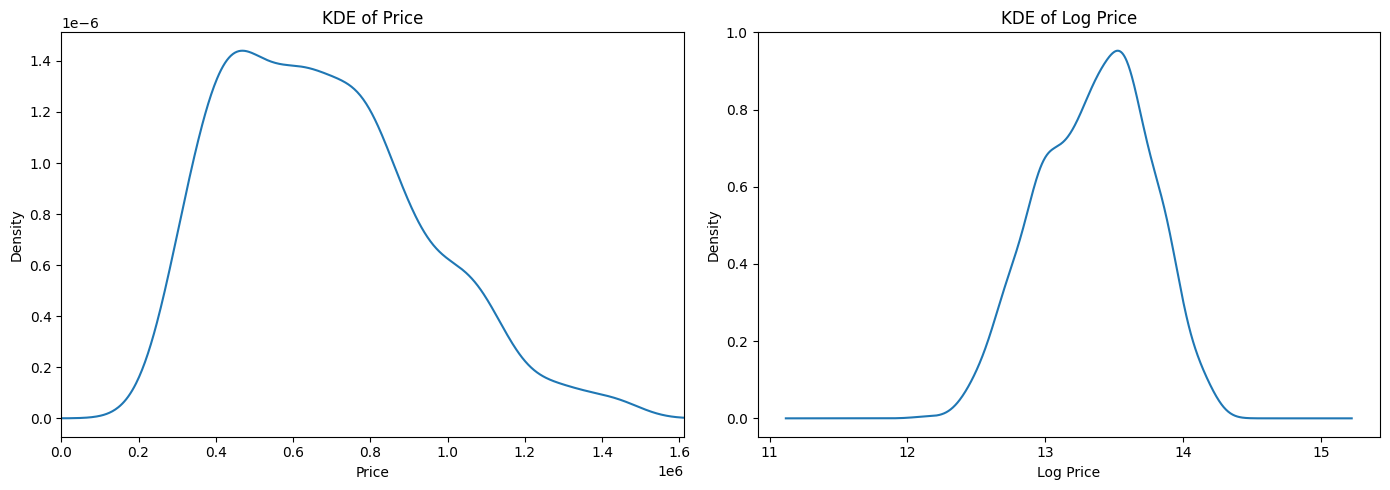

Price by Make:
               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        6.0  4.535000e+05  246606.366503   267000.0   288500.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           72.0  7.887222e+05  253474.460320   316000.0   580750.0   
Hyundai        304.0  6.884375e+05  273012.825123   248000.0   484750.0   
Jeep             1.0  1.290000e+06            NaN  1290000.0  1290000.0   
Kia              1.0  1.369000e+06            NaN  1369000.0  1369000.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  216019.860943   237000.0   411000.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.625735e+05  214827.338943   287000.0   475000.0   
Skoda     

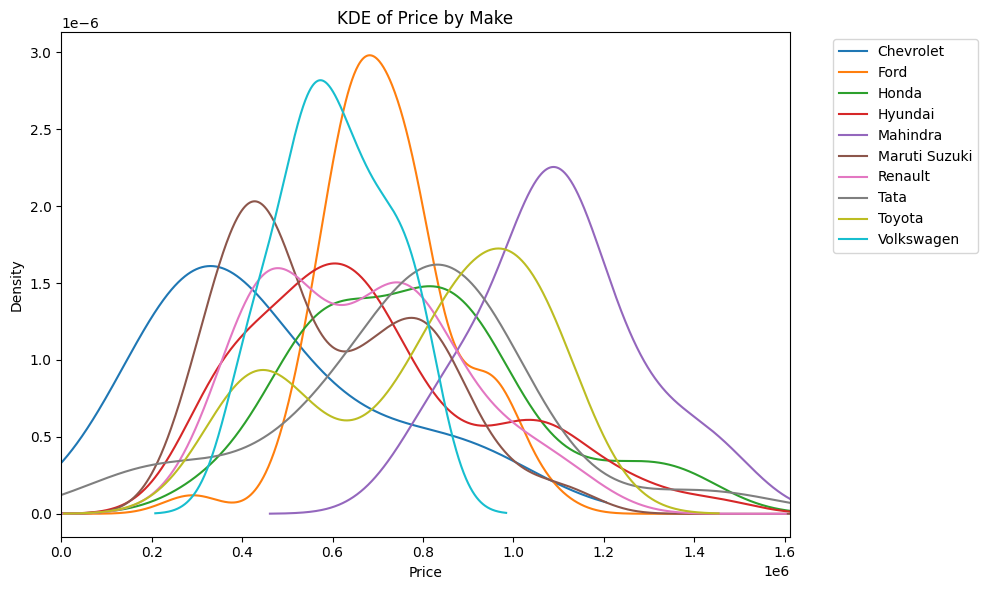

Avg price by brand (highest first):
Make
Kia              1.369000e+06
Jeep             1.290000e+06
Mahindra         1.100167e+06
Nissan           8.842500e+05
Toyota           8.003400e+05
Honda            7.887222e+05
Tata             7.662941e+05
Ford             7.211731e+05
Hyundai          6.884375e+05
Skoda            6.847500e+05
Renault          6.625735e+05
Volkswagen       6.058276e+05
Maruti Suzuki    5.887850e+05
Chevrolet        4.535000e+05
Datsun           2.896667e+05
Name: Price, dtype: float64


In [9]:
#Q3.2 - summarize price, kde plots, grouped by make
print('Price summary:')
print(cars['Price'].describe())
print()

#kde plots for price and log price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cars['Price'].plot.kde(ax=axes[0])
axes[0].set_title('KDE of Price')
axes[0].set_xlabel('Price')
axes[0].set_xlim(0, cars['Price'].max() * 1.1)

cars['log_Price'].plot.kde(ax=axes[1])
axes[1].set_title('KDE of Log Price')
axes[1].set_xlabel('Log Price')
plt.tight_layout()
plt.show()

#describe by brand
print('Price by Make:')
print(cars.groupby('Make')['Price'].describe())
print()

#grouped kde by make (only brands with enough data)
fig, ax = plt.subplots(figsize=(10, 6))
for name, group in cars.groupby('Make'):
    if len(group) >= 5:
        group['Price'].plot.kde(ax=ax, label=name)
ax.set_title('KDE of Price by Make')
ax.set_xlabel('Price')
ax.set_xlim(0, cars['Price'].max() * 1.1)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#avg price sorted to see which brands cost the most
print('Avg price by brand (highest first):')
print(cars.groupby('Make')['Price'].mean().sort_values(ascending=False))
#prices are right skewed, most cars cluster in the lower range
#with some expensive outliers pulling the tail to the right

In [10]:
#Q3.3 - train/test split
numeric_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity']
categorical_cols = ['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission', 'Transmission_Type', 'No_of_Owners']

y_cars = cars['Price']

X_train_cars, X_test_cars, y_train_cars, y_test_cars = train_test_split(
    cars, y_cars, test_size=0.2, random_state=42
)

print(f'Train size: {len(X_train_cars)}')
print(f'Test size: {len(X_test_cars)}')

Train size: 737
Test size: 185


In [11]:
#Q3.4 - three models: numeric only, categorical only, then both together

#model 1: just the numeric columns
X_train_num = X_train_cars[numeric_cols].copy()
X_test_num = X_test_cars[numeric_cols].copy()

model_num = LinearRegression()
model_num.fit(X_train_num, y_train_cars)

y_pred_train_num = model_num.predict(X_train_num)
y_pred_test_num = model_num.predict(X_test_num)

r2_train_num = r2_score(y_train_cars, y_pred_train_num)
rmse_train_num = np.sqrt(mean_squared_error(y_train_cars, y_pred_train_num))
r2_test_num = r2_score(y_test_cars, y_pred_test_num)
rmse_test_num = np.sqrt(mean_squared_error(y_test_cars, y_pred_test_num))

print('Numeric only:')
print(f'  Train R2: {r2_train_num:.4f}, RMSE: {rmse_train_num:.4f}')
print(f'  Test R2: {r2_test_num:.4f}, RMSE: {rmse_test_num:.4f}')
print()

#model 2: just categoricals (one hot, drop first for dummy trap)
X_train_cat = pd.get_dummies(X_train_cars[categorical_cols], drop_first=True, dtype=float)
X_test_cat = pd.get_dummies(X_test_cars[categorical_cols], drop_first=True, dtype=float)

#make sure test has same columns as train
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

model_cat = LinearRegression()
model_cat.fit(X_train_cat, y_train_cars)

y_pred_train_cat = model_cat.predict(X_train_cat)
y_pred_test_cat = model_cat.predict(X_test_cat)

r2_train_cat = r2_score(y_train_cars, y_pred_train_cat)
rmse_train_cat = np.sqrt(mean_squared_error(y_train_cars, y_pred_train_cat))
r2_test_cat = r2_score(y_test_cars, y_pred_test_cat)
rmse_test_cat = np.sqrt(mean_squared_error(y_test_cars, y_pred_test_cat))

print('Categorical only:')
print(f'  Train R2: {r2_train_cat:.4f}, RMSE: {rmse_train_cat:.4f}')
print(f'  Test R2: {r2_test_cat:.4f}, RMSE: {rmse_test_cat:.4f}')
print()

#model 3: everything together
X_train_all = pd.concat([X_train_num.reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
X_test_all = pd.concat([X_test_num.reset_index(drop=True), X_test_cat.reset_index(drop=True)], axis=1)

model_all = LinearRegression()
model_all.fit(X_train_all, y_train_cars.reset_index(drop=True))

y_pred_train_all = model_all.predict(X_train_all)
y_pred_test_all = model_all.predict(X_test_all)

r2_train_all = r2_score(y_train_cars, y_pred_train_all)
rmse_train_all = np.sqrt(mean_squared_error(y_train_cars, y_pred_train_all))
r2_test_all = r2_score(y_test_cars, y_pred_test_all)
rmse_test_all = np.sqrt(mean_squared_error(y_test_cars, y_pred_test_all))

print('Combined:')
print(f'  Train R2: {r2_train_all:.4f}, RMSE: {rmse_train_all:.4f}')
print(f'  Test R2: {r2_test_all:.4f}, RMSE: {rmse_test_all:.4f}')
print()

#side by side comparison
print('Test set comparison:')
print(f'  Numeric    - R2: {r2_test_num:.4f}, RMSE: {rmse_test_num:.4f}')
print(f'  Categorical - R2: {r2_test_cat:.4f}, RMSE: {rmse_test_cat:.4f}')
print(f'  Combined   - R2: {r2_test_all:.4f}, RMSE: {rmse_test_all:.4f}')
#combined does the best which makes sense, more info = better predictions

Numeric only:
  Train R2: 0.3532, RMSE: 203508.9435
  Test R2: 0.2853, RMSE: 225913.6458

Categorical only:
  Train R2: 0.6122, RMSE: 157576.4919
  Test R2: 0.5282, RMSE: 183540.0107

Combined:
  Train R2: 0.7642, RMSE: 122862.3565
  Test R2: 0.7406, RMSE: 136087.3792

Test set comparison:
  Numeric    - R2: 0.2853, RMSE: 225913.6458
  Categorical - R2: 0.5282, RMSE: 183540.0107
  Combined   - R2: 0.7406, RMSE: 136087.3792


/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid

In [12]:
#Q3.5 - polynomial features on the numeric vars
#need to scale first otherwise the big numbers blow up
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

print('Trying different polynomial degrees:')
print()

best_r2 = -np.inf
best_degree = 1
best_rmse = np.inf

for degree in range(1, 6):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_num_scaled)
    X_test_poly = poly.transform(X_test_num_scaled)
    
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train_cars)
    
    y_pred_train_poly = model_poly.predict(X_train_poly)
    y_pred_test_poly = model_poly.predict(X_test_poly)
    
    r2_train_poly = r2_score(y_train_cars, y_pred_train_poly)
    rmse_train_poly = np.sqrt(mean_squared_error(y_train_cars, y_pred_train_poly))
    r2_test_poly = r2_score(y_test_cars, y_pred_test_poly)
    rmse_test_poly = np.sqrt(mean_squared_error(y_test_cars, y_pred_test_poly))
    
    print(f'Degree {degree}: {X_train_poly.shape[1]} features')
    print(f'  Train R2: {r2_train_poly:.4f}, RMSE: {rmse_train_poly:.4f}')
    print(f'  Test R2: {r2_test_poly:.4f}, RMSE: {rmse_test_poly:.4f}')
    
    if r2_test_poly < 0:
        print(f'  R2 went negative here, overfitting!')
    
    if r2_test_poly > best_r2:
        best_r2 = r2_test_poly
        best_degree = degree
        best_rmse = rmse_test_poly
    print()

print(f'Best degree: {best_degree} (R2: {best_r2:.4f}, RMSE: {best_rmse:.4f})')
print(f'Combined model from part 4: R2: {r2_test_all:.4f}, RMSE: {rmse_test_all:.4f}')
#the combined model from part 4 still beats the polynomial models
#because the categorical info (brand, body type etc) matters a lot for price

Trying different polynomial degrees:

Degree 1: 3 features
  Train R2: 0.3532, RMSE: 203508.9435
  Test R2: 0.2853, RMSE: 225913.6458

Degree 2: 9 features
  Train R2: 0.3975, RMSE: 196401.8302
  Test R2: 0.2921, RMSE: 224834.0492

Degree 3: 19 features
  Train R2: 0.4159, RMSE: 193379.3455
  Test R2: 0.3075, RMSE: 222378.0828

Degree 4: 34 features
  Train R2: 0.4194, RMSE: 192812.4159
  Test R2: 0.3099, RMSE: 221994.6004

Degree 5: 55 features
  Train R2: 0.4238, RMSE: 192068.4075
  Test R2: 0.2948, RMSE: 224402.8087

Best degree: 4 (R2: 0.3099, RMSE: 221994.6004)
Combined model from part 4: R2: 0.7406, RMSE: 136087.3792


/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/rfx/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid

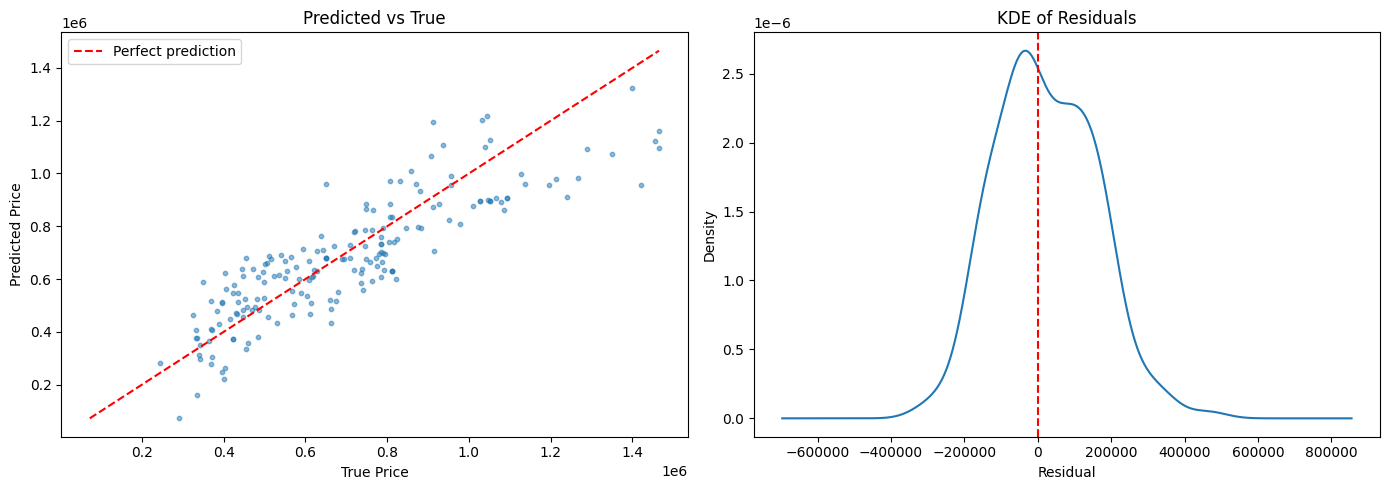

Mean residual: 22013.2514
Std of residuals: 134295.1657



In [13]:
#Q3.6 - plot predicted vs actual and look at residuals
#using the combined model since it was the best
y_pred_best = y_pred_test_all
residuals = y_test_cars.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#scatter of predicted vs true
axes[0].scatter(y_test_cars, y_pred_best, alpha=0.5, s=10)
min_val = min(y_test_cars.min(), y_pred_best.min())
max_val = max(y_test_cars.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[0].set_xlabel('True Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Predicted vs True')
axes[0].legend()

#residual kde
pd.Series(residuals).plot.kde(ax=axes[1])
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_title('KDE of Residuals')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.4f}')
print(f'Std of residuals: {residuals.std():.4f}')
print()

#the points kind of follow the diagonal but theres a lot of spread,
#especially for pricier cars where we tend to underpredict.
#residuals are roughly centered near zero and somewhat bell shaped
#but the tails are a bit heavy.
#strengths: the model does a decent job overall with an R2 around 0.74
#weaknesses: struggles with the higher priced cars, and a log transform
#on price might help since the distribution is skewed

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is 
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

1. SSE = sum_{i=1}^{N} (y_i - b_0 - b_1 * z_{i1} - b_2 * z_{i2})^2

2. Partial derivatives, set to 0:
dSSE/db_0 = -2 * sum(y_i - b_0 - b_1*z_{i1} - b_2*z_{i2}) = 0
dSSE/db_1 = -2 * sum(z_{i1} * (y_i - b_0 - b_1*z_{i1} - b_2*z_{i2})) = 0
dSSE/db_2 = -2 * sum(z_{i2} * (y_i - b_0 - b_1*z_{i1} - b_2*z_{i2})) = 0

3. Let e_i = y_i - b_0 - b_1*z_{i1} - b_2*z_{i2} be the error.
The first equation says sum(e_i) = 0 so the average error is zero.
The second says sum(z_{i1} * e_i) = 0 so e is orthogonal to z_1.
The third says sum(z_{i2} * e_i) = 0 so e is orthogonal to z_2.
Same properties as in simple regression.

4. From the first equation:
sum(y_i) - N*b_0 - b_1*sum(z_{i1}) - b_2*sum(z_{i2}) = 0
But sum(z_{ij}) = 0 since the z's are centered, so:
sum(y_i) = N*b_0 --> b_0* = y_bar

Plugging b_0* = y_bar back into the other two equations (the b_0 terms drop out because sum(z_{ij}) = 0):
sum(z_{i1} * y_i) = b_1 * sum(z_{i1}^2) + b_2 * sum(z_{i1}*z_{i2})
sum(z_{i2} * y_i) = b_1 * sum(z_{i1}*z_{i2}) + b_2 * sum(z_{i2}^2)

5. This is Ab = C where:
A = [[sum(z_{i1}^2), sum(z_{i1}*z_{i2})],
     [sum(z_{i1}*z_{i2}), sum(z_{i2}^2)]]
b = [b_1, b_2]^T
C = [sum(z_{i1}*y_i), sum(z_{i2}*y_i)]^T

6. Divide by N and sub z_{ij} = x_{ij} - m_j:
(1/N)*sum(z_{ij}^2) = (1/N)*sum((x_{ij} - m_j)^2) = Var(x_j)
(1/N)*sum(z_{i1}*z_{i2}) = (1/N)*sum((x_{i1}-m_1)(x_{i2}-m_2)) = Cov(x_1,x_2)
(1/N)*sum(z_{ij}*y_i) = (1/N)*sum((x_{ij}-m_j)*y_i) = Cov(x_j,y)

So A/N is the variance-covariance matrix of the x's:
[[Var(x_1), Cov(x_1,x_2)],
 [Cov(x_1,x_2), Var(x_2)]]

And C/N is the covariance of each x with y:
[Cov(x_1,y), Cov(x_2,y)]^T

So basically the regression coefficients come from the variance-covariance structure of the data. If x_1 and x_2 arent correlated then Cov(x_1,x_2) = 0 and each coefficient is just Cov(x_j,y)/Var(x_j), same as simple regression. But when theyre correlated the system has to adjust for shared variation between x_1 and x_2, which ties back to the multicollinearity idea from Q1.